In [ ]:
import pickle
import torch
import evaluate
import os
import csv

import numpy as np
import matplotlib.pyplot as plt

from contextlib import nullcontext
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from torch import nn
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
from huggingface_hub import login
from transformers import AutoImageProcessor, ViTForImageClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from dotenv import load_dotenv

In [ ]:
### Login for Hugging Face model
load_dotenv()
login(token=os.environ["HF_TOKEN"])

### Setam seedul pt random
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.cuda.manual_seed_all(SEED)

### Variabile globale
MODEL_NAME = "google/vit-large-patch16-224"
SPOSE_PATH = "spose_embedding_49d_sorted.txt"
IMAGE_SIZE = 224
EVAL_RESIZE = 256 

### VIT processor + move device to cuda
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast = True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Augmentare inspirata din cum augumenteaza lucrarea datele pentru CUB
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
])

eval_transform = transforms.Compose([
    transforms.Resize(EVAL_RESIZE, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMAGE_SIZE),
])

### Dataset pentru x -> c -> y
class ConceptDataset(Dataset):
    def __init__(self, images_paths, labels_49d, labels, aug=None):
        self.images_paths = images_paths
        self.concepts = labels_49d
        self.labels = labels
        self.aug = aug

    def __len__(self):
        return len(self.images_paths)

    def __getitem__(self, idx):
        img = Image.open(self.images_paths[idx]).convert("RGB")
        
        if self.aug is not None:
            img = self.aug(img)
            
        inputs = image_processor(
            images=img, 
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False
        )
        
        pixel_values = inputs["pixel_values"].squeeze(0)
        concepts = torch.tensor(self.concepts[idx], dtype=torch.float32)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        
        return {
            "pixel_values": pixel_values, 
            "concept_labels": concepts, 
            "labels": label_tensor
        }
        
### Metricile pe care le va urmarii modelul
accuracy_metric = evaluate.load("accuracy")
f1_metric       = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric   = evaluate.load("recall")

def compute_metrics(eval_pred):
    preds  = eval_pred.predictions
    labels = eval_pred.label_ids

    logits     = preds[0]
    pred_conc  = preds[1]
    true_labels = labels[0]
    true_conc   = labels[1]

    predictions = np.argmax(logits, axis=-1)
    mse = float(np.mean((pred_conc - true_conc) ** 2))
    r2  = r2_score(true_conc, pred_conc)

    return {
        "accuracy":   accuracy_metric.compute(predictions=predictions, references=true_labels)["accuracy"],
        "f1":         f1_metric.compute(predictions=predictions, references=true_labels, average="macro")["f1"],
        "precision":  precision_metric.compute(predictions=predictions, references=true_labels, average="macro")["precision"],
        "recall":     recall_metric.compute(predictions=predictions, references=true_labels, average="macro")["recall"],
        "mse":        mse,
        "r2":         r2,
    }

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
class BottleneckViT(nn.Module):
    """
    Concept Bottleneck Model modular — suporta 3 moduri:
      - "joint":       ViT (x→c) + classifier (c→y) antrenate end-to-end cu Loss = CE + λ·MSE
      - "independent": ViT inghetat; classifier antrenat pe concepte REALE c; la test foloseste ĉ = ViT(x)
      - "sequential":  ViT inghetat; classifier antrenat pe concepte PREZISE ĉ = ViT(x)
    """
    def __init__(self, vit_path, num_concepts, num_classes, mode="joint", lambda_weight=1.0, **kwargs):
        super().__init__()
        self.mode = mode
        self.vit = ViTForImageClassification.from_pretrained(vit_path, **kwargs)
        self.classifier = nn.Linear(num_concepts, num_classes)
        
        self.lambda_weight = lambda_weight
        self.task_loss_fct = nn.CrossEntropyLoss()
        self.concept_loss_fct = nn.MSELoss()
        
        # Pentru independent/sequential, inghetam ViT-ul (x->c deja antrenat)
        if mode in ("independent", "sequential"):
            for param in self.vit.parameters():
                param.requires_grad = False

    def forward(self, pixel_values, labels=None, concept_labels=None):
        # x → c (concepte prezise)
        ctx = torch.no_grad() if self.mode in ("independent", "sequential") else nullcontext()
        with ctx:
            pred_concepts = self.vit(pixel_values=pixel_values).logits
        
        # Alegem inputul pentru classifier
        if self.mode == "independent" and self.training and concept_labels is not None:
            # Independent: la antrenare folosim conceptele REALE
            classifier_input = concept_labels
        else:
            # Sequential / Joint / Eval: folosim conceptele prezise
            classifier_input = pred_concepts
        
        # c → y
        logits = self.classifier(classifier_input)
        
        output = {"logits": logits, "pred_concepts": pred_concepts}
        
        # Calculam loss-ul
        if labels is not None and concept_labels is not None:
            task_loss = self.task_loss_fct(logits, labels)
            
            if self.mode == "joint":
                concept_loss = self.concept_loss_fct(pred_concepts, concept_labels)
                loss = task_loss + self.lambda_weight * concept_loss
            else:
                # Independent si Sequential: doar CE loss
                loss = task_loss
            
            output["loss"] = loss
            
        return output

In [5]:
### Load images + labels parsing
with open("all_images.pkl", "rb") as f:
    imgs_path = pickle.load(f)
    
spose_mat = np.loadtxt(SPOSE_PATH)

label_names = {name: i for i, name in enumerate(list(imgs_path.keys()))}
all_data = []
all_labels = []
all_concepts = []

for s in imgs_path:
    np.random.shuffle(imgs_path[s])

    label = label_names[s]
    con = spose_mat[label]

    for img_path in imgs_path[s]:
        all_data.append(img_path)
        all_labels.append(label)
        all_concepts.append(con)

print(len(all_data), len(all_labels), len(all_concepts))

# 80% din date pentru train si 20% pt test
aux_data, test_data, aux_labels, test_labels, aux_concepts, test_concepts = train_test_split(
    all_data, all_labels, all_concepts,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels
)

# Alegem 20% din datele de train pentru evaluare
train_data, eval_data, train_labels, eval_labels, train_concepts, eval_concepts = train_test_split(
    aux_data, aux_labels, aux_concepts,
    test_size=0.20,
    random_state=SEED,
    stratify=aux_labels
)

train_dataset = ConceptDataset(train_data, train_concepts, train_labels, train_transform)
eval_dataset = ConceptDataset(eval_data, eval_concepts, eval_labels, eval_transform)
test_dataset = ConceptDataset(test_data, test_concepts, test_labels, eval_transform)

26107 26107 26107



Training cu lambda = 0.01



Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Mse,Lambda Mse,R2
1,7.409875,7.046349,0.046924,0.030558,0.031914,0.041307,0.371774,0.003718,-4.961956
2,5.807048,4.907603,0.667944,0.603282,0.620198,0.651366,1.702000,0.017020,-28.529266
3,3.093148,2.242072,0.885803,0.867031,0.889372,0.880879,5.167339,0.051673,-90.248100
4,0.866168,0.863496,0.933684,0.925564,0.944367,0.931437,9.053021,0.090530,-158.295944
5,0.296262,0.595645,0.943021,0.936812,0.953428,0.941280,11.622427,0.116224,-205.153061
6,0.185548,0.518789,0.952358,0.946638,0.961354,0.950315,11.649012,0.116490,-205.652847
7,0.153157,0.512102,0.951879,0.945778,0.960386,0.949910,11.160443,0.111604,-195.870682
8,0.150106,0.485877,0.954034,0.948115,0.960770,0.952382,10.784803,0.107848,-189.946625
9,0.138261,0.507860,0.951879,0.946655,0.960994,0.950494,10.576974,0.105770,-185.786118
10,0.146632,0.499423,0.950922,0.944788,0.959687,0.948382,10.325672,0.103257,-182.101929


c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


Test Results (lambda=0.01):
Accuracy:   0.9575
F1:         0.9546
Precision:  0.9684
Recall:     0.9560
Total Loss: 0.4050
CE Loss:    0.3187
MSE:        8.637282
Lambda*MSE: 0.086373
R²:         -152.0482
Metrics salvate in ./vit_joint/lambda_0.01\checkpoints\result.csv


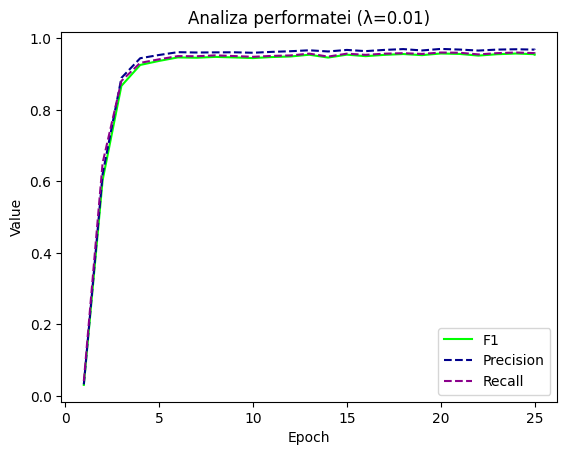


Training cu lambda = 0.1



Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Mse,Lambda Mse,R2
1,7.406427,7.056670,0.053148,0.033559,0.032742,0.046881,0.365659,0.036566,-5.020441
2,5.860625,5.030178,0.685420,0.629182,0.647783,0.671422,1.498996,0.149900,-25.435841
3,3.409803,2.721288,0.900886,0.885623,0.907053,0.896647,4.461156,0.446116,-78.325729
4,1.542942,1.641109,0.934163,0.925791,0.944267,0.931122,6.938704,0.693870,-122.364594
5,1.079531,1.385920,0.941824,0.935281,0.951459,0.940831,7.006641,0.700664,-122.972893
6,0.914764,1.263135,0.950682,0.944832,0.959585,0.949056,6.598015,0.659801,-115.236717
7,0.839837,1.168020,0.954513,0.949330,0.962734,0.952967,6.256835,0.625683,-109.324280
8,0.788971,1.132015,0.956428,0.951309,0.964725,0.954854,6.040458,0.604046,-105.502075
9,0.766045,1.093157,0.958822,0.954797,0.967656,0.957551,5.889502,0.588950,-102.745995
10,0.744067,1.081025,0.956189,0.951752,0.964884,0.954899,5.731164,0.573116,-100.112244


c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


Test Results (lambda=0.1):
Accuracy:   0.9581
F1:         0.9550
Precision:  0.9683
Recall:     0.9564
Total Loss: 0.9775
CE Loss:    0.4602
MSE:        5.172849
Lambda*MSE: 0.517285
R²:         -90.5234
Metrics salvate in ./vit_joint/lambda_0.1\checkpoints\result.csv


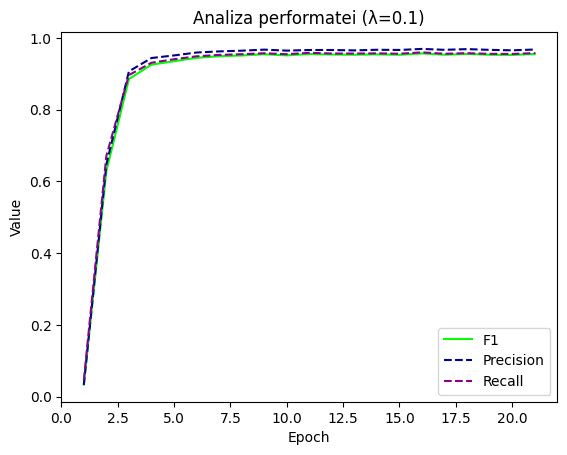


Training cu lambda = 1.0



Loading weights:   0%|          | 0/392 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Mse,Lambda Mse,R2
1,7.468557,7.295600,0.035432,0.021284,0.022525,0.032902,0.069165,0.069165,-0.153253
2,6.571415,6.119224,0.761312,0.713727,0.738491,0.747600,0.567340,0.567340,-8.969599
3,5.426431,5.223516,0.922911,0.909969,0.928440,0.918716,1.295439,1.295439,-21.967125
4,4.674262,4.707353,0.952119,0.946573,0.961725,0.950135,1.865573,1.865573,-32.027283
5,4.332590,4.499146,0.953555,0.949556,0.966348,0.951978,2.051888,2.051888,-35.211617
6,4.146289,4.359047,0.958343,0.953974,0.967808,0.957147,2.074926,2.074926,-35.697598
7,4.014431,4.239218,0.957864,0.953121,0.965453,0.956562,2.081880,2.081880,-35.772118
8,3.909198,4.146568,0.961456,0.957480,0.969795,0.960428,2.087015,2.087015,-35.863163
9,3.840348,4.063952,0.962892,0.958968,0.970586,0.961462,2.070882,2.070882,-35.647293
10,3.770350,3.997716,0.961695,0.957302,0.969356,0.960203,2.073139,2.073139,-35.682461


c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


Test Results (lambda=1.0):
Accuracy:   0.9650
F1:         0.9627
Precision:  0.9730
Recall:     0.9637
Total Loss: 3.7743
CE Loss:    1.7390
MSE:        2.035274
Lambda*MSE: 2.035274
R²:         -35.0311
Metrics salvate in ./vit_joint/lambda_1.0\checkpoints\result.csv


c:\Users\pasca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


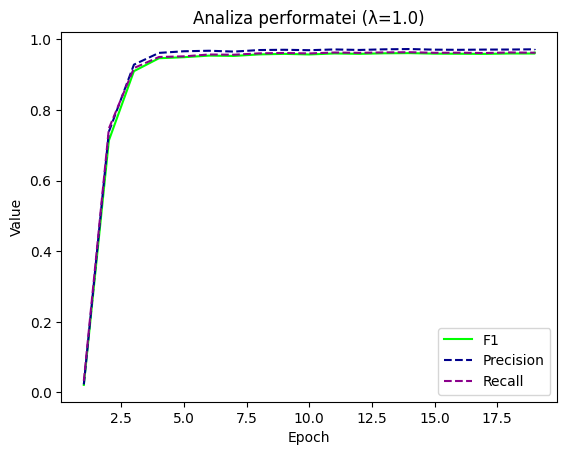

In [ ]:
# ===== CONFIGURARE =====
# Alege modul: "joint", "independent" sau "sequential"
MODE = "independent"
# Lambda-uri — folosite doar pentru modul "joint"
LAMBDAS = [0.01, 0.1, 1.0]

# Construim lista de configuratii
if MODE == "joint":
    configs = [{"lam": l, "run_dir": f"./vit_joint/lambda_{l}"} for l in LAMBDAS]
else:
    # Independent si Sequential: o singura rulare, fara lambda
    configs = [{"lam": 0.0, "run_dir": f"./vit_{MODE}/run1"}]

for cfg in configs:
    lam = cfg["lam"]
    run_dir = cfg["run_dir"]

    print(f"\n{'='*50}")
    print(f"Mode: {MODE}" + (f" | Lambda: {lam}" if MODE == "joint" else ""))
    print(f"{'='*50}\n")

    model = BottleneckViT(
        vit_path="./vit_feature_prediction/run1/models",
        num_concepts=49,
        num_classes=len(imgs_path.keys()),
        mode=MODE,
        lambda_weight=lam,
        ignore_mismatched_sizes=True
    )
    model = model.to(device)

    checkpoint_dir = os.path.join(run_dir, "checkpoints")
    model_dir      = os.path.join(run_dir, "models")
    os.makedirs(checkpoint_dir, exist_ok=True)
    os.makedirs(model_dir,      exist_ok=True)

    args = TrainingArguments(
        output_dir=checkpoint_dir,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,
        num_train_epochs=30,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        remove_unused_columns=False,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=5)],
    )
    trainer.label_names = ["labels", "concept_labels"]

    trainer.train()
    trainer.save_model(model_dir)

    # --- Test ---
    trainer.callback_handler.callbacks = [
        cb for cb in trainer.callback_handler.callbacks
        if cb.__class__.__name__ in ["ProgressCallback", "DefaultFlowCallback", "PrinterCallback"]
    ]
    test_results = trainer.evaluate(test_dataset)
    test_mse = test_results.get("eval_mse", float("nan"))
    test_r2  = test_results.get("eval_r2",  float("nan"))

    print(f"\nTest Results (mode={MODE}" + (f", lambda={lam}" if MODE == "joint" else "") + "):")
    print(f"Accuracy:   {test_results['eval_accuracy']:.4f}")
    print(f"F1:         {test_results['eval_f1']:.4f}")
    print(f"Precision:  {test_results['eval_precision']:.4f}")
    print(f"Recall:     {test_results['eval_recall']:.4f}")
    print(f"Loss:       {test_results['eval_loss']:.4f}")
    print(f"MSE:        {test_mse:.6f}")
    print(f"R²:         {test_r2:.4f}")
    if MODE == "joint":
        print(f"CE Loss:    {test_results['eval_loss'] - lam * test_mse:.4f}")
        print(f"Lambda*MSE: {lam * test_mse:.6f}")

    with open(os.path.join(run_dir, "test_results.txt"), "w") as f:
        f.write(f"Test Results (mode={MODE}" + (f", lambda={lam}" if MODE == "joint" else "") + "):\n")
        f.write(f"Accuracy:   {test_results['eval_accuracy']:.4f}\n")
        f.write(f"F1:         {test_results['eval_f1']:.4f}\n")
        f.write(f"Precision:  {test_results['eval_precision']:.4f}\n")
        f.write(f"Recall:     {test_results['eval_recall']:.4f}\n")
        f.write(f"Loss:       {test_results['eval_loss']:.4f}\n")
        f.write(f"MSE:        {test_mse:.6f}\n")
        f.write(f"R²:         {test_r2:.4f}\n")
        if MODE == "joint":
            f.write(f"CE Loss:    {test_results['eval_loss'] - lam * test_mse:.4f}\n")
            f.write(f"Lambda*MSE: {lam * test_mse:.6f}\n")

    # --- CSV per epoch ---
    eval_history = [e for e in trainer.state.log_history if "eval_loss" in e]
    csv_path = os.path.join(checkpoint_dir, "result.csv")

    if MODE == "joint":
        fieldnames = ["epoch", "total_loss", "ce_loss", "mse", "lambda_mse", "r2", "accuracy", "f1", "precision", "recall"]
    else:
        fieldnames = ["epoch", "loss", "mse", "r2", "accuracy", "f1", "precision", "recall"]

    with open(csv_path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for entry in eval_history:
            mse_val    = entry.get("eval_mse", float("nan"))
            r2_val     = entry.get("eval_r2",  float("nan"))
            row = {
                "epoch":     entry["epoch"],
                "mse":       mse_val,
                "r2":        r2_val,
                "accuracy":  entry.get("eval_accuracy", ""),
                "f1":        entry.get("eval_f1", ""),
                "precision": entry.get("eval_precision", ""),
                "recall":    entry.get("eval_recall", ""),
            }
            if MODE == "joint":
                total_loss = entry["eval_loss"]
                row["total_loss"] = total_loss
                row["ce_loss"]    = total_loss - lam * mse_val
                row["lambda_mse"] = lam * mse_val
            else:
                row["loss"] = entry["eval_loss"]
            writer.writerow(row)
    print(f"Metrics salvate in {csv_path}")

    # --- Plot ---
    epochs, f1s, precs, recs = [], [], [], []
    with open(csv_path, "r") as f:
        for row in csv.DictReader(f):
            epochs.append(float(row["epoch"]))
            f1s.append(float(row["f1"])        if row["f1"]        else np.nan)
            precs.append(float(row["precision"]) if row["precision"] else np.nan)
            recs.append(float(row["recall"])    if row["recall"]    else np.nan)

    plt.figure()
    plt.plot(epochs, f1s,   c="lime",        label="F1")
    plt.plot(epochs, precs, c="darkblue",    ls="--", label="Precision")
    plt.plot(epochs, recs,  c="darkmagenta", ls="--", label="Recall")
    title = f"Analiza performantei ({MODE}"
    if MODE == "joint":
        title += f", λ={lam}"
    title += ")"
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.savefig(os.path.join(checkpoint_dir, "performance.pdf"))
    plt.show()

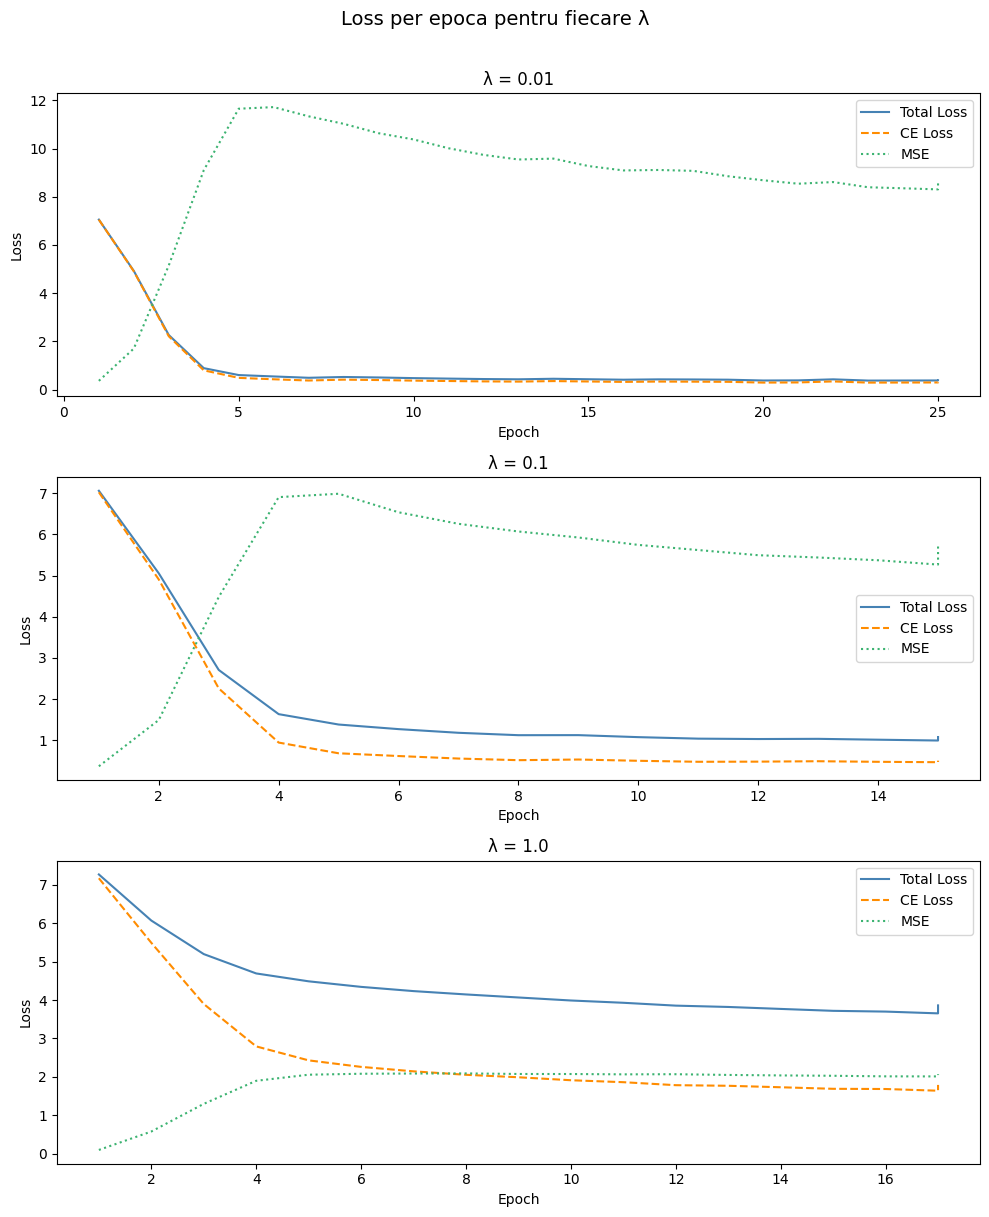

In [ ]:
# --- Comparatie Loss-uri pentru Joint (per lambda) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for ax, lam in zip(axes, [0.01, 0.1, 1.0]):
    csv_path = f"./vit_joint/lambda_{lam}/checkpoints/result.csv"

    epochs, total_losses, ce_losses, mses = [], [], [], []
    with open(csv_path, "r") as f:
        for row in csv.DictReader(f):
            epochs.append(float(row["epoch"]))
            total_losses.append(float(row["total_loss"]))
            ce_losses.append(float(row["ce_loss"]))
            mses.append(float(row["mse"]))

    ax.plot(epochs, total_losses, c="steelblue",   label="Total Loss")
    ax.plot(epochs, ce_losses,    c="darkorange",  ls="--", label="CE Loss")
    ax.plot(epochs, mses,         c="mediumseagreen", ls=":",  label="MSE")
    ax.set_title(f"Joint — λ = {lam}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.suptitle("Loss per epoca pentru fiecare λ (Joint)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("./vit_joint/loss_comparison.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# --- R² per epoca (Joint, per lambda) ---
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

print(f"{'Lambda':<10} {'R² (test)':<12}")
print("-" * 25)

for ax, lam in zip(axes, [0.01, 0.1, 1.0]):
    csv_path = f"./vit_joint/lambda_{lam}/checkpoints/result.csv"
    txt_path = f"./vit_joint/lambda_{lam}/test_results.txt"

    epochs, r2s = [], []
    with open(csv_path, "r") as f:
        for row in csv.DictReader(f):
            epochs.append(float(row["epoch"]))
            r2s.append(float(row["r2"]) if row.get("r2") else np.nan)

    test_r2 = float("nan")
    with open(txt_path, "r") as f:
        for line in f:
            if line.startswith("R²:"):
                test_r2 = float(line.split(":")[1].strip())
    print(f"{lam:<10} {test_r2:<12.4f}")

    ax.plot(epochs, r2s, c="steelblue", label="R²")
    ax.axhline(0, color="gray", ls="--", lw=0.8)
    ax.set_title(f"R² per epoca — Joint λ = {lam}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("R²")
    ax.legend()

plt.suptitle("R² per epoca pentru fiecare λ (Joint)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("./vit_joint/r2_comparison.pdf", bbox_inches="tight")
plt.show()

In [ ]:
# --- Comparatie finala: Independent vs Sequential vs Joint (toate modurile) ---
print(f"{'Mode':<20} {'Accuracy':<10} {'F1':<10} {'Precision':<10} {'Recall':<10} {'Loss':<10} {'MSE':<12} {'R²':<10}")
print("-" * 95)

results_all = []

# Citim rezultatele pentru fiecare mod
mode_configs = [
    ("Independent",      "./vit_independent/run1/test_results.txt"),
    ("Sequential",       "./vit_sequential/run1/test_results.txt"),
    ("Joint λ=0.01",     "./vit_joint/lambda_0.01/test_results.txt"),
    ("Joint λ=0.1",      "./vit_joint/lambda_0.1/test_results.txt"),
    ("Joint λ=1.0",      "./vit_joint/lambda_1.0/test_results.txt"),
]

for mode_name, txt_path in mode_configs:
    if not os.path.exists(txt_path):
        print(f"{mode_name:<20} — fisierul nu exista inca")
        continue
    
    metrics = {}
    with open(txt_path, "r") as f:
        for line in f:
            for key in ["Accuracy", "F1", "Precision", "Recall", "Loss", "MSE", "R²"]:
                if line.strip().startswith(key + ":"):
                    metrics[key] = float(line.split(":")[1].strip())
    
    results_all.append({"mode": mode_name, **metrics})
    print(f"{mode_name:<20} {metrics.get('Accuracy', float('nan')):<10.4f} {metrics.get('F1', float('nan')):<10.4f} "
          f"{metrics.get('Precision', float('nan')):<10.4f} {metrics.get('Recall', float('nan')):<10.4f} "
          f"{metrics.get('Loss', float('nan')):<10.4f} {metrics.get('MSE', float('nan')):<12.6f} "
          f"{metrics.get('R²', float('nan')):<10.4f}")

# --- Barplot comparativ F1 ---
if results_all:
    modes = [r["mode"] for r in results_all]
    f1s   = [r.get("F1", 0) for r in results_all]
    accs  = [r.get("Accuracy", 0) for r in results_all]

    x = np.arange(len(modes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    bars1 = ax.bar(x - width/2, accs, width, label="Accuracy", color="steelblue")
    bars2 = ax.bar(x + width/2, f1s,  width, label="F1",       color="mediumseagreen")

    ax.set_ylabel("Score")
    ax.set_title("Comparatie: Independent vs Sequential vs Joint")
    ax.set_xticks(x)
    ax.set_xticklabels(modes, rotation=15, ha="right")
    ax.legend()
    ax.set_ylim(0.9, 1.0)

    for bar in bars1 + bars2:
        h = bar.get_height()
        ax.annotate(f"{h:.4f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

    plt.tight_layout()
    plt.savefig("./comparatie_moduri.pdf", bbox_inches="tight")
    plt.show()